# <b>Customer Churn Prediction</b>

## <b> EDA SUMMARY</b>

### <b>Business Problem: </b>

Customer churn is one of the most important metrics for subscription-based businesses. Acquiring a new customer is significantly more expensive than retaining an existing one.

#### <b>Objective: </b>
- Understand customer behavior
- Identify factors influencing churn
- Discover high-risk customer segments
- Generate insights for retention strategies
- Build a foundation for churn prediction models

### <b>Step 1: Import the Required Libraries</b>

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### <b>Step 2: Load the dataset</b>

In [2]:
# Load the Dataset
df = pd.read_csv('../data/processed/churn_processed.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### <b>Step 3: Dataset Overview</b>
#### Objective : 
Understand the dataset structure and data quality before performing analysis.

In [3]:
# Basic Information
print(f"Shape: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")

Shape: (7043, 20)
Data Types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
Missing Values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthl

#### <b>Insights:</b>
- The dataset contains 7,043 customer records and 20 variables.
- No missing values were found after preprocessing, making the dataset suitable for machine learning and business analysis.
- The dataset contains both numerical and categorical variables representing customer demographics, services subscribed, billing information, and churn status.

### <b>Step 4: Churn Distribution Analysis</b>
#### Objective :
Determine the overall churn rate and understand the balance between retained and lost customers.

In [4]:
# Churn Distribution
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [5]:
# Churn Percentage
churn_pct = round(df['Churn'].value_counts(normalize=True)*100,2)
churn_pct

Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

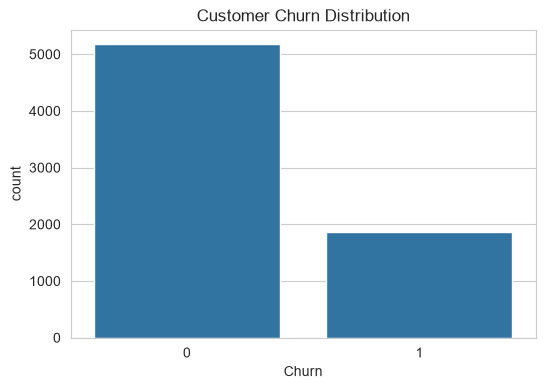

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='Churn',
    data=df
)
plt.title("Customer Churn Distribution")
plt.show()

#### <b>Insights:</b>
- Approximately 26.5% of customers have churned while 73.5% remain active.
- Although the dataset is somewhat imbalanced, the churn rate is significant enough to justify predictive modeling efforts.
- This indicates that nearly one out of every four customers leaves the company.

### <b>Step 5: Gender vs Churn</b>
#### Objective :
Evaluate whether gender influences customer retention.

In [7]:
# Gender Vs Churn
pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
)*100

Churn,0,1
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


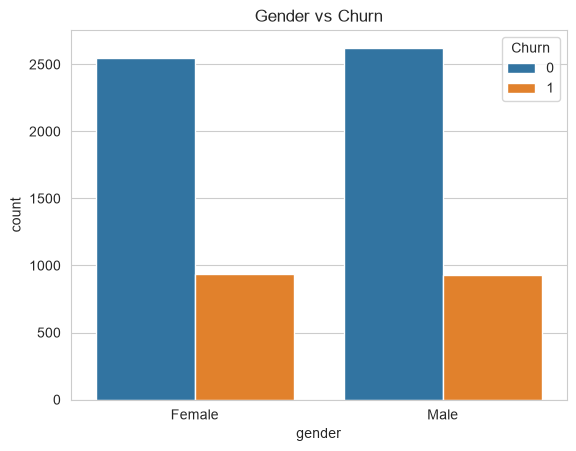

In [8]:
sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title("Gender vs Churn")
plt.show()

#### <b>Insights:</b>
- Churn rates are relatively similar across male and female customers.
- This suggests that gender is not a strong predictor of churn and may contribute little to model performance.

### <b>Step 6: Contract Type vs Churn</b>
#### Objective :
Understand how contract commitments affect customer retention.

In [9]:
# Contract Type vs Churn
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100
contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


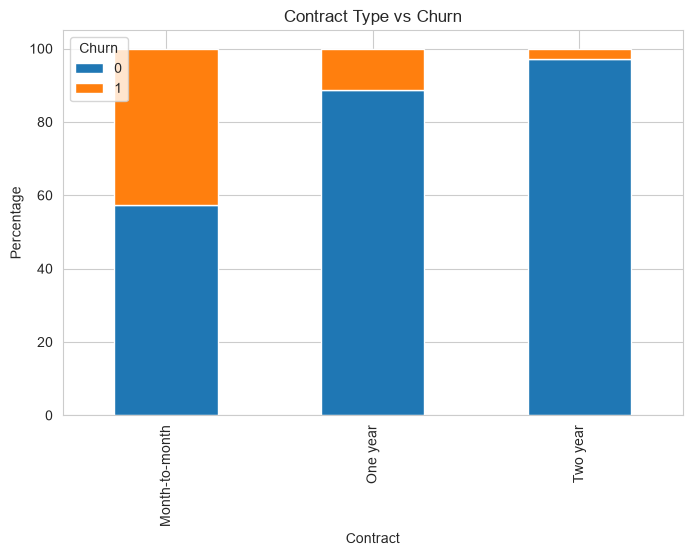

In [10]:
contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.ylabel("Percentage")
plt.show()

#### <b>Insights:</b>
- Customers on month-to-month contracts show substantially higher churn rates compared to those on one-year or two-year contracts.
- Long-term contracts appear to be highly effective in improving customer retention.
- Contract type is expected to be one of the most important features in churn prediction.

##### Business Recommendation
- Encourage customers to migrate from month-to-month plans to annual plans through discounts and loyalty programs.

### <b>Step 7: Tenure Analysis</b>
#### Objective :
Examine customer loyalty and relationship duration.

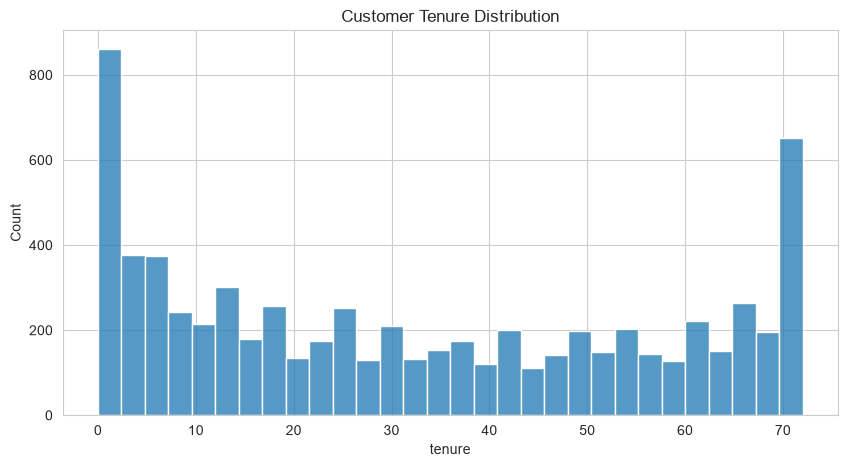

In [11]:
# Tenure Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='tenure',
    bins=30
)
plt.title("Customer Tenure Distribution")
plt.show()

#### <b>Insights:</b>
- The distribution shows a large concentration of new customers and a substantial number of long-term customers.
- Understanding churn behavior across tenure groups is critical for customer retention strategies.

### <b>Step 8: Tenure vs Churn</b>
#### Objective :
Assess whether customer tenure impacts churn.

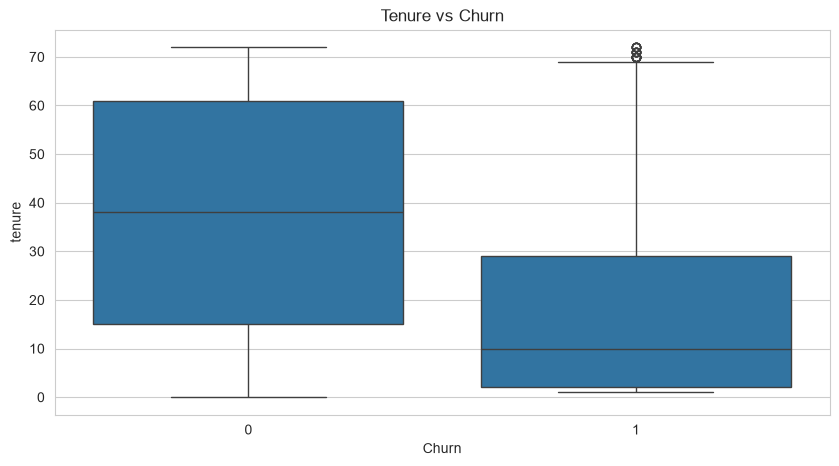

In [12]:
# Tenure vs Churn
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)
plt.title("Tenure vs Churn")
plt.show()

#### <b>Insights:</b>
- Customers who churn generally have much lower tenure compared to retained customers.
- This indicates that churn risk is highest during the early stages of the customer lifecycle.
- Customer onboarding and early engagement programs may reduce churn significantly.

### <b>Step 9: Monthly Charges vs Churn
#### Objective :
Investigate the relationship between pricing and churn.

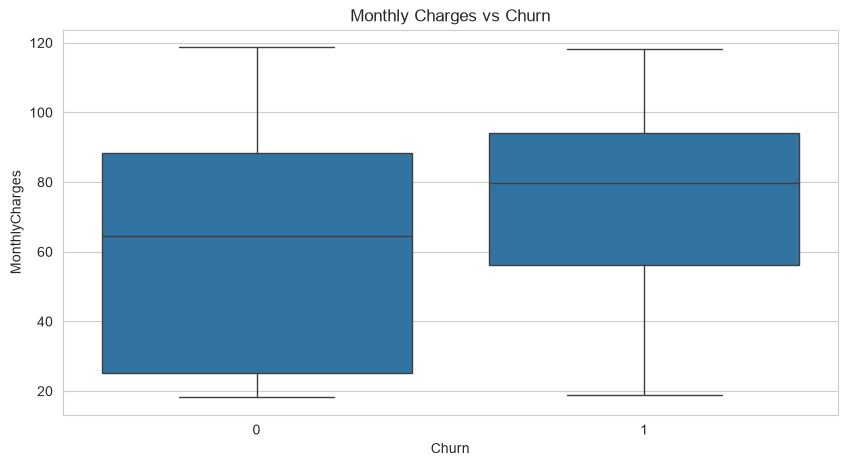

In [13]:
# Monthly Charges vs Churn
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.title("Monthly Charges vs Churn")
plt.show()

#### <b>Insights:</b>
- Customers who churn tend to pay higher monthly charges.
- Price sensitivity may be a major factor contributing to customer attrition.
- The company may need to review pricing strategies or improve value-added services for premium customers.

### <b>Step 10: Senior Citizen Analysis</b>
#### Objective : 
Determine whether older customers are more likely to leave.

In [14]:
citizen_churn = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
)*100

citizen_churn

Churn,0,1
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


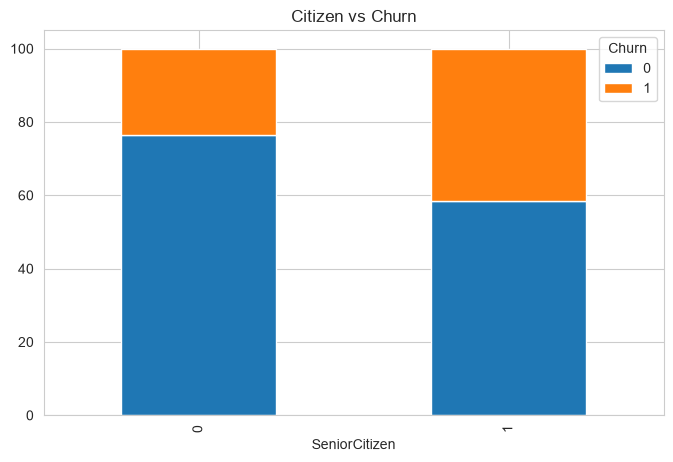

In [15]:
citizen_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Citizen vs Churn")
plt.show()

#### <b>Insights:</b>
- Senior citizens generally exhibit higher churn rates than non-senior customers.
- This customer segment may require targeted retention campaigns and improved customer support.

### <b>Step 11: Internet Service Analysis</b>
#### Objective :
Analyze churn across internet service categories.

In [16]:
# Internet Service vs Churn
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)*100

internet_churn

Churn,0,1
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


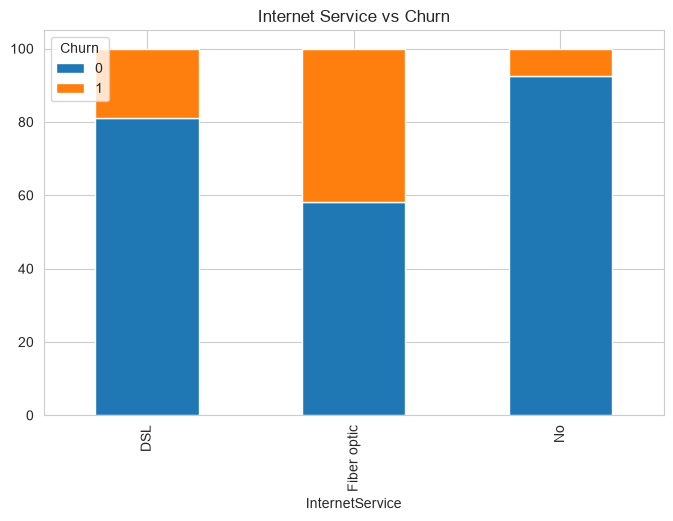

In [17]:
internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.show()

#### <b>Insights:</b>
- Certain internet service categories demonstrate higher churn rates than others.
- Service quality, pricing, and customer satisfaction may differ across service types, contributing to varying retention levels.

### <b>Step 12: Payment Method Analysis</b>
#### Objective :
Identify whether payment preferences influence churn.

In [18]:
# Payment Method vs Churn
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)*100

payment_churn

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


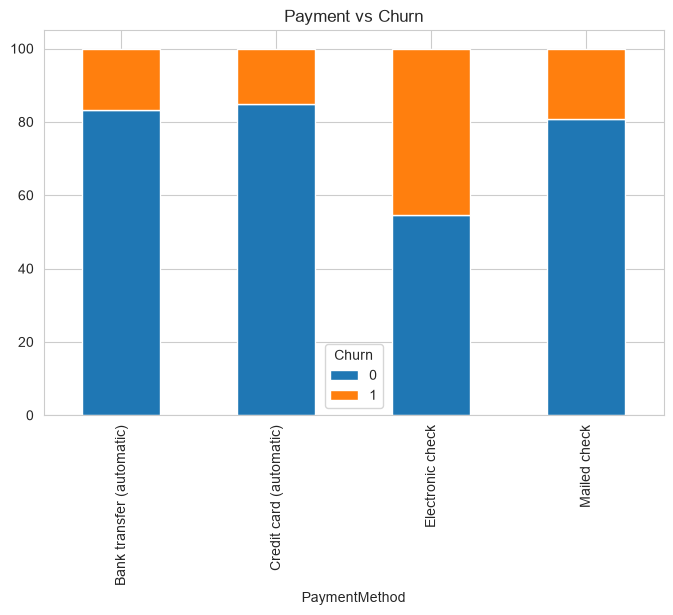

In [19]:
payment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("Payment vs Churn")
plt.show()

#### <b>Insights:</b>
- Electronic check users typically exhibit the highest churn rates.
- Customers using automated payment methods often show better retention, likely due to reduced payment friction.

##### Business Recommendation
- Promote automatic payment enrollment to improve customer retention.

### <b>Step13: Correlation Analysis</b>
#### Objective :
Identify variables most strongly associated with churn.

In [20]:
# Correaltion Analysis
## firt convert categorical variables
eda_df = df.copy()

for col in eda_df.select_dtypes(include='object').columns:
    eda_df[col] = eda_df[col].astype('category').cat.codes

C:\Users\abhil\AppData\Local\Temp\ipykernel_16560\4162323804.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in eda_df.select_dtypes(include='object').columns:


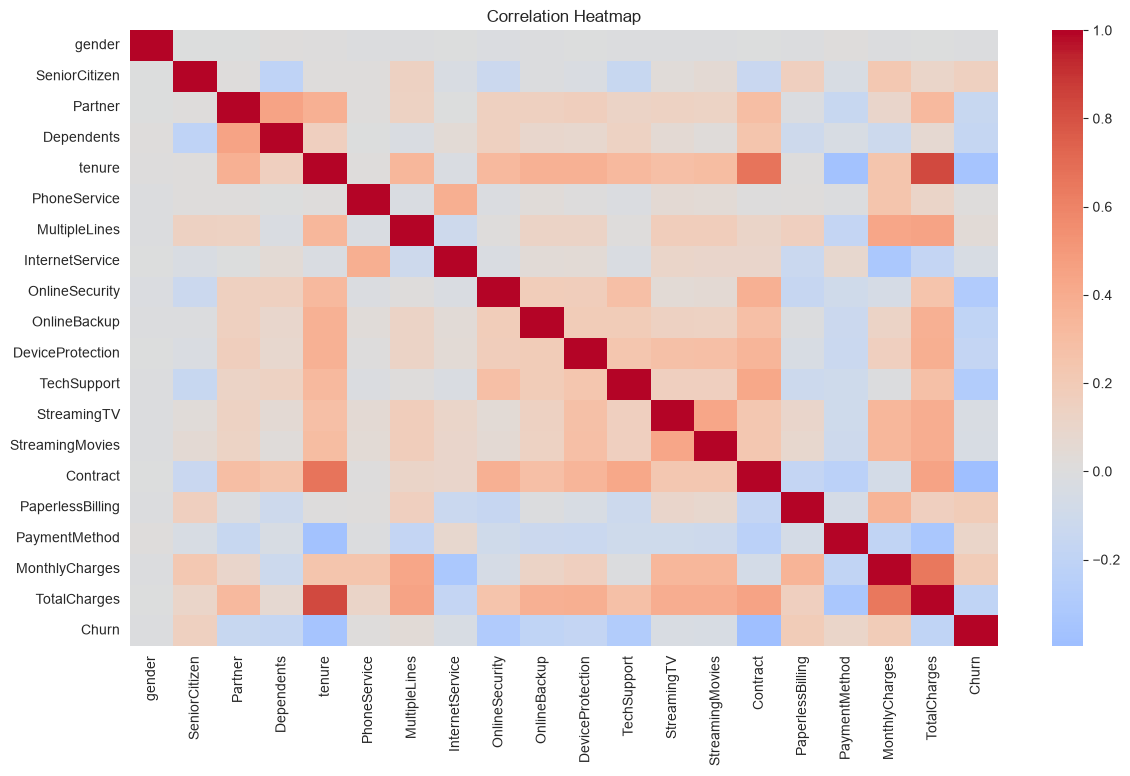

In [21]:
## Heatmap
plt.figure(figsize=(14,8))
sns.heatmap(
    eda_df.corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

#### <b>Insights:</b>
- Correlation analysis helps identify candidate features for machine learning models.
- Variables with strong positive or negative relationships with churn are likely to contribute significantly to predictive performance.

### <b>Step 14: Top Correaltion with Churn</b>
#### Objective :
Rank features according to their relationship with customer churn.

In [22]:
corr = eda_df.corr()['Churn']
corr = corr.sort_values(ascending=False)
print(corr)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


#### <b>Insights:</b>
- Features such as contract type, tenure, monthly charges, and service subscriptions are expected to demonstrate the strongest relationships with churn.
- These variables will likely become the most influential predictors in the classification models developed later in the project.

### <b>CONCLUSION : </b>
1. Customers on month-to-month contracts are the most likely to churn.
2. New customers exhibit substantially higher churn risk than long-term customers.
3. Customers with higher monthly charges are more likely to leave.
4. Senior citizens show elevated churn rates.
5. Payment methods influence retention, with electronic check users displaying the highest churn levels.
6. Contract duration, tenure, and pricing appear to be the strongest drivers of churn.
7. Customer retention efforts should focus on early-stage customers and month-to-month subscribers.

## <b> FEATURE ENGINEERING ANALYSIS</b>

### <b> Objective:</b>
Evaluate whether the newly engineered features are associated with customer churn and understand their business impact.

### <b> Step 1: Load the featured dataset</b>

In [23]:
featured_df = pd.read_csv('../data/processed/churn_featured.csv')
featured_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,IsLongTermCustomer,IsHighValueCustomer,HasFamily,NumServices,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,0,0,1,1,New
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,1,0,0,3,Established
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,0,0,0,3,New
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,1,0,0,3,Established
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,0,1,0,1,New


### <b> Step 2: Featured Dataset Overview</b>

In [24]:
# Basic Information
print(f"Shape: {featured_df.shape}")
print(f"\nData Types:\n{featured_df.dtypes}")
print(f"\nMissing Values:\n{featured_df.isnull().sum()}")

Shape: (7043, 26)

Data Types:
gender                     str
SeniorCitizen            int64
Partner                    str
Dependents                 str
tenure                   int64
PhoneService               str
MultipleLines              str
InternetService            str
OnlineSecurity             str
OnlineBackup               str
DeviceProtection           str
TechSupport                str
StreamingTV                str
StreamingMovies            str
Contract                   str
PaperlessBilling           str
PaymentMethod              str
MonthlyCharges         float64
TotalCharges           float64
Churn                    int64
AvgMonthlySpend        float64
IsLongTermCustomer       int64
IsHighValueCustomer      int64
HasFamily                int64
NumServices              int64
TenureGroup                str
dtype: object

Missing Values:
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneSe

### <b> Step 3: Long-Term Customer Analysis</b>
#### Objective :
Determine whether long-term customers are less likely to churn.

In [25]:
long_term_churn = pd.crosstab(
    featured_df['IsLongTermCustomer'],
    featured_df['Churn'],
    normalize='index'
)*100

long_term_churn

Churn,0,1
IsLongTermCustomer,,
0,58.023107,41.976893
1,85.714286,14.285714


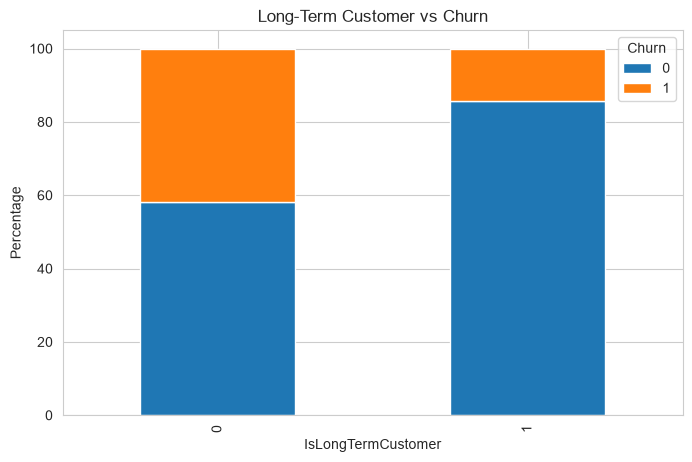

In [26]:
long_term_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("Long-Term Customer vs Churn")
plt.ylabel("Percentage")
plt.show()

#### <b>Insights:</b>
- Customers with tenure of 24 months or more exhibit substantially lower churn rates.
- This indicates that customer retention improves significantly after the first two years.
- The early customer lifecycle is therefore the highest-risk period for churn.

#### Business Recommendation:
- Focus retention campaigns on customers within their first 24 months.

### <b>Step 4: High-Value Customer Analysis</b>
#### Objective :
Analyze churn behavior among high-spending customers.

In [27]:
high_value_churn = pd.crosstab(
    featured_df['IsHighValueCustomer'],
    featured_df['Churn'],
    normalize='index',
)*100

high_value_churn

Churn,0,1
IsHighValueCustomer,,
0,82.086168,17.913832
1,64.807966,35.192034


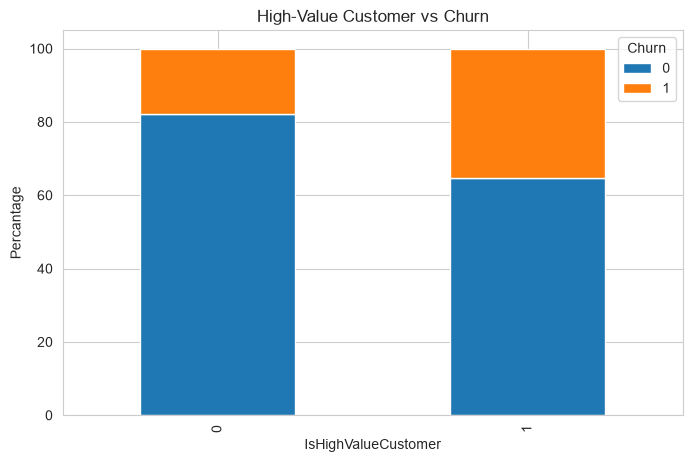

In [28]:
high_value_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("High-Value Customer vs Churn")
plt.ylabel("Percantage")
plt.show()

#### <b>Insights:</b>
- High-value customers generate greater revenue but may exhibit higher churn rates due to increased expectations and pricing sensitivity.
- Losing these customers has a disproportionate impact on revenue.

#### Business Recommendation:
- Create premium loyalty programs for high-value customers.

### <b>Step 5: Family Customer Analysis</b>
#### Objective :
Determine whether customers with partners or dependents are more loyal.

In [29]:
family_churn = pd.crosstab(
    featured_df['HasFamily'],
    featured_df['Churn'],
    normalize='index'
)*100

family_churn

Churn,0,1
HasFamily,,
0,65.762195,34.237805
1,80.175392,19.824608


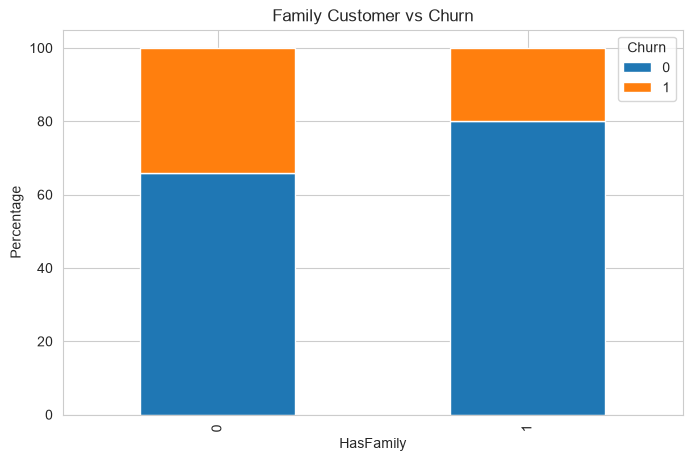

In [30]:
family_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("Family Customer vs Churn")
plt.ylabel("Percentage")
plt.show()

#### <b>Insights:</b>
- Customers with partners or dependents generally show lower churn rates.
- Family customers are often more stable and less likely to switch providers.

#### Business Recommendation:
- Introduce family bundles and multi-user discounts to improve retention.

### <b>Step 6: Number of Services Analysis</b>
#### Objective :
Investigate whether service adoption affects churn.

In [31]:
service_churn = featured_df.groupby("NumServices")["Churn"].mean().reset_index()

service_churn['Churn']*=100

service_churn

,NumServices,Churn
0,0,43.750000
1,1,21.105232
2,2,32.828283
3,3,36.476684
4,4,31.344902
5,5,25.550661
6,6,22.485207
7,7,12.405063
8,8,5.288462


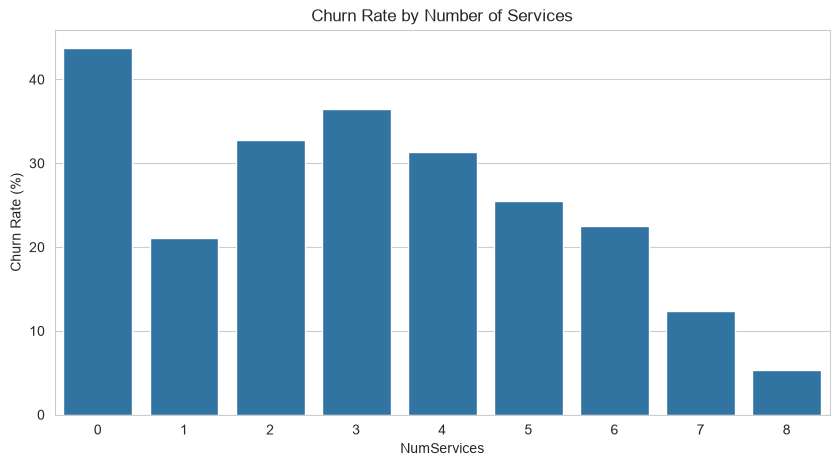

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=service_churn,
    x='NumServices',
    y='Churn'
)
plt.title("Churn Rate by Number of Services")
plt.ylabel("Churn Rate (%)")
plt.show()

#### <b>Insights:</b>
- Customers subscribed to multiple services tend to exhibit lower churn rates.
- Additional services increase customer engagement and create switching costs.

#### Business Recommendation:
- Promote bundled service packages to increase customer stickiness.

### <b>Step 7: Tenure Group Analysis</b>
#### Objective :
Identify churn patterns across customer lifecycle stages.

In [33]:
tenure_group_churn = pd.crosstab(
    featured_df['TenureGroup'],
    featured_df['Churn'],
    normalize='index'
)*100

tenure_group_churn

Churn,0,1
TenureGroup,,
Developing,71.289062,28.710938
Established,79.611041,20.388959
Loyal,90.486824,9.513176
New,52.561757,47.438243


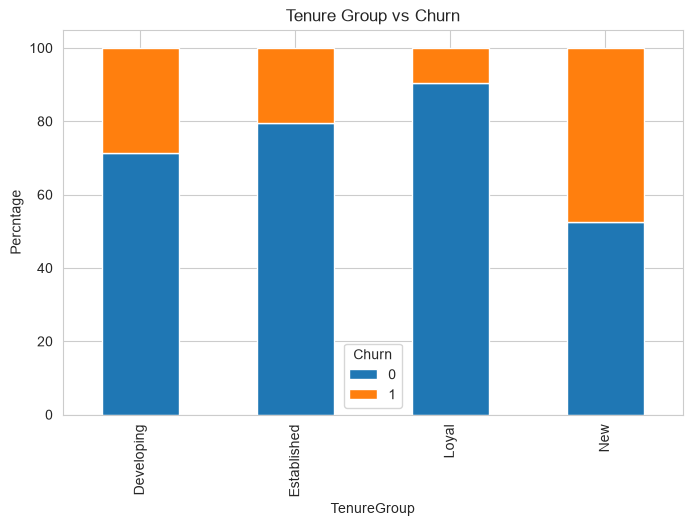

In [34]:
tenure_group_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("Tenure Group vs Churn")
plt.ylabel("Percntage")
plt.show()

#### <b>Insights:</b>
- New customers exhibit the highest churn rates.
- Churn declines steadily as customers move from Developing to Established and Loyal categories.
- Customer retention improves significantly over time.

#### Business Recommendation:
- Strengthen onboarding and engagement programs for new customers.

### <b>Step 8: Average Monthly Spend Analysis</b>
#### Objective :
Compare spending behavior between churned and retained customers.

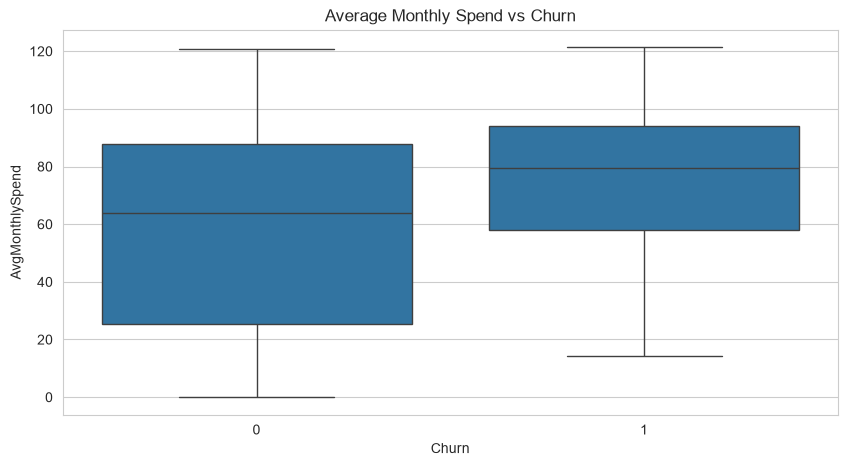

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Churn',
    y='AvgMonthlySpend',
    data=featured_df
)
plt.title("Average Monthly Spend vs Churn")
plt.show()

#### <b>Insights:</b>
- Customers with higher average spending may show increased churn risk if they perceive insufficient value.
- Pricing strategy and service quality should be continuously monitored for premium customers.

### <b>Feature Engineering Summary:</b>
1. Long-term customers are significantly less likely to churn.
2. New customers represent the highest-risk segment.
3. Family customers demonstrate stronger retention.
4. Customers using more services are generally more loyal.
5. High-value customers require proactive retention strategies.
6. Customer lifecycle stage is a strong predictor of churn.
7. Service bundling and long-term contracts appear to be effective retention mechanisms.